## Vendor Performance Analysis

This project analyzes vendor performance, sales, profitability, and inventory efficiency using Python and SQL.


In [ ]:
#Importing Required Libraries
#In this step, we import all necessary libraries for data processing, analysis, and visualization.
    
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [ ]:
#Loading Data from Database
#Here, we connect to the SQLite database and fetch the cleaned vendor summary data for analysis.

con = sqlite3.connect('inventory.db')

#Ftching vendors summary data
df = pd.read_sql_query('Select * From vendor_sales_summary', con)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseAmount,TotalSalesQuantity,TotalSalesAmount,TotalSalesPrice,TotalExciseTax,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnover,TotalPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


## Exploratory Data Analysis
- Previously, we examined various tables in the database to indentify key variable, understanding the relationship, and determine which one should be included in the analysis.
- In the phase of EDA we will analyse the resultant to gain insights into the distribution of each column, this will help us understand data pattern, identify anomalies and ensure data quality before proceeding further analysis.

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseAmount,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesAmount,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


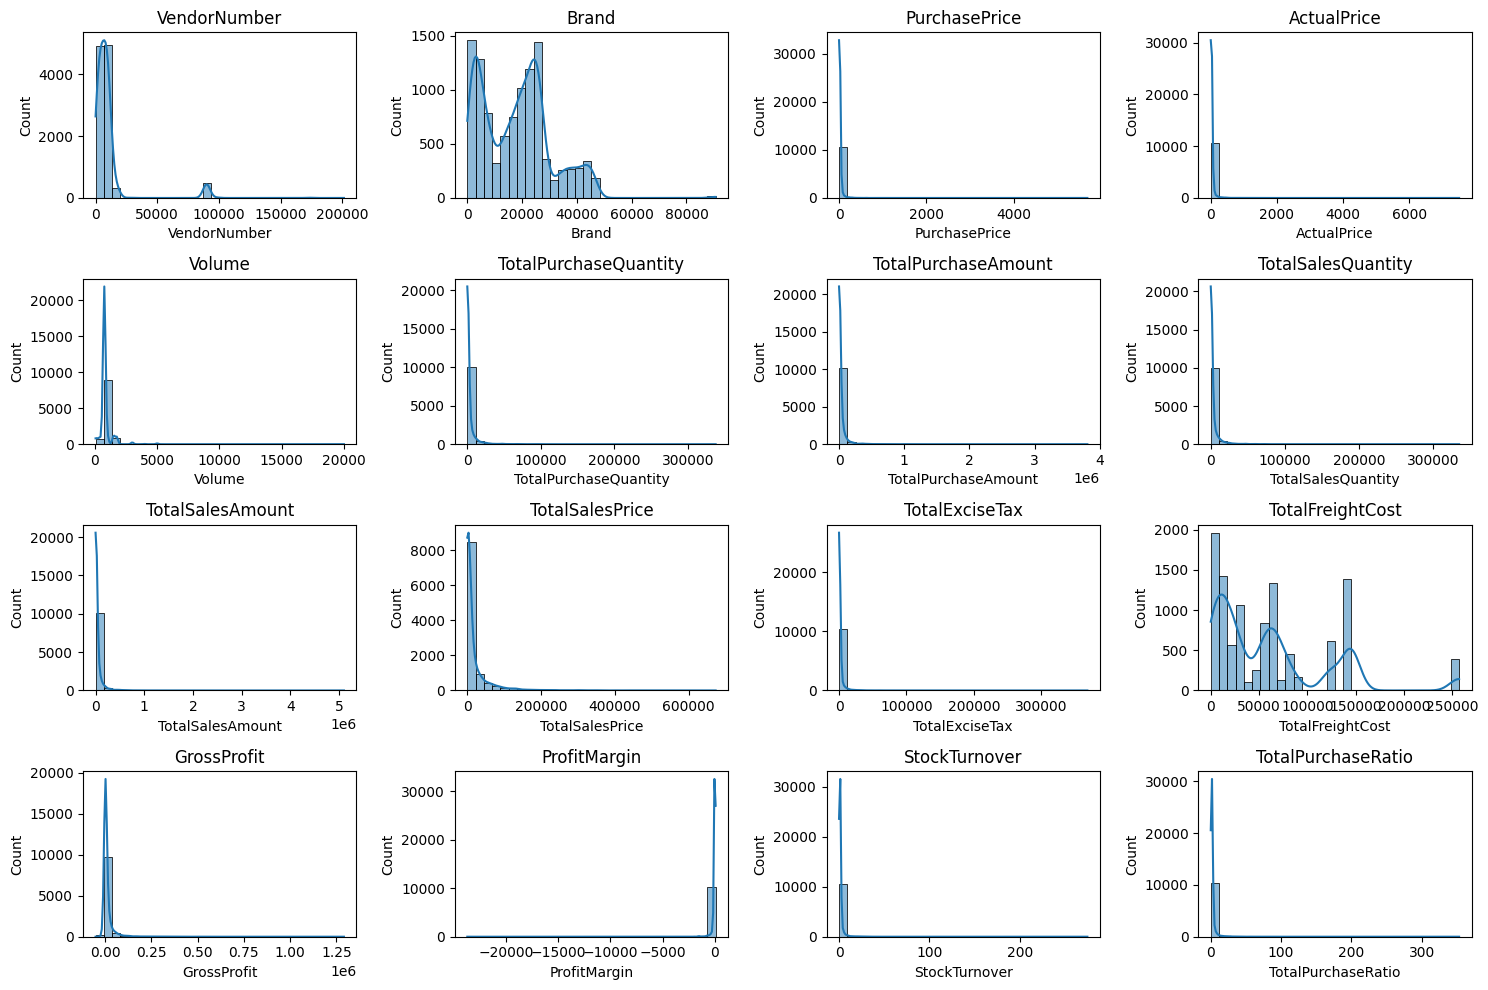

In [4]:
#Distribution Plots for numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize = (15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)# adjust grid layout as needed mean 4 rows and 4 columns i+1- position of current chart(1st column- 1st position and 2nd column- 2nd posotion)  
    sns.histplot(df[col], kde = True, bins = 30)
    plt.title(col)
plt.tight_layout() # fix equal spacing between graphs
plt.show()

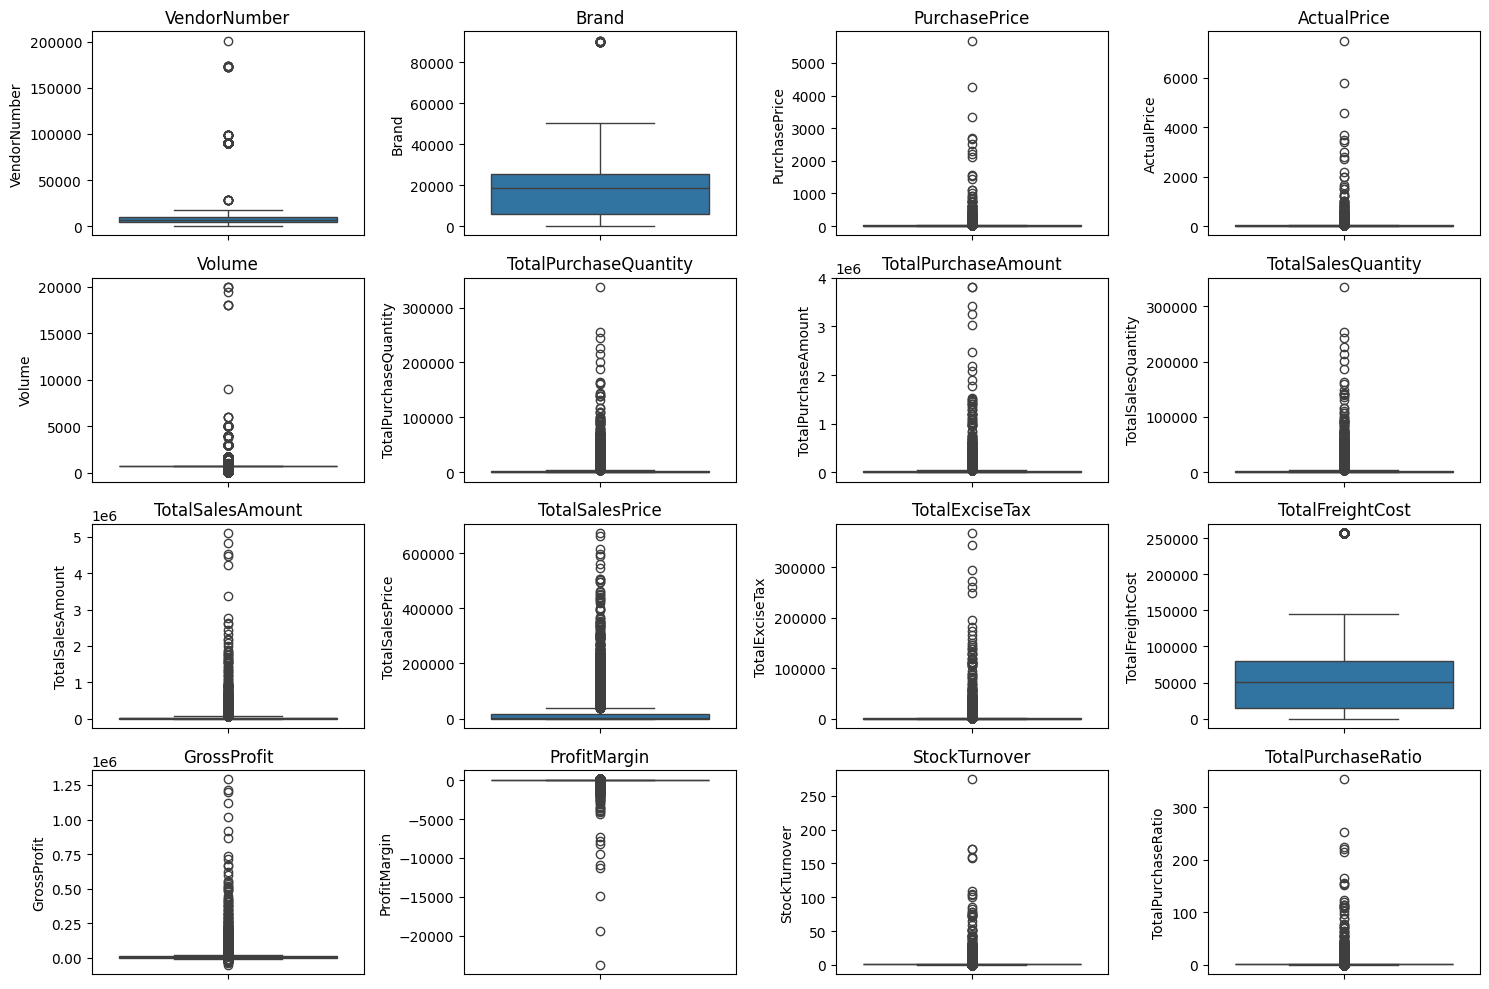

In [5]:
#Distribution Plots for numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize = (15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) #upgrade grid layout as needed
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Summary Statistics Insights:
**Negative & Zero Values:**

- Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price..
- Profit Margin: Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.
- Total Sales Quantity & Sales Amount: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

**Outliers Indicated by High Standard Deviations:**

- Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
- Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
- Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [6]:
# Filtering the data by removing inconsistencies
df = pd.read_sql_query("""SELECT * 
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""",con)

df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseAmount,TotalSalesQuantity,TotalSalesAmount,TotalSalesPrice,TotalExciseTax,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnover,TotalPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


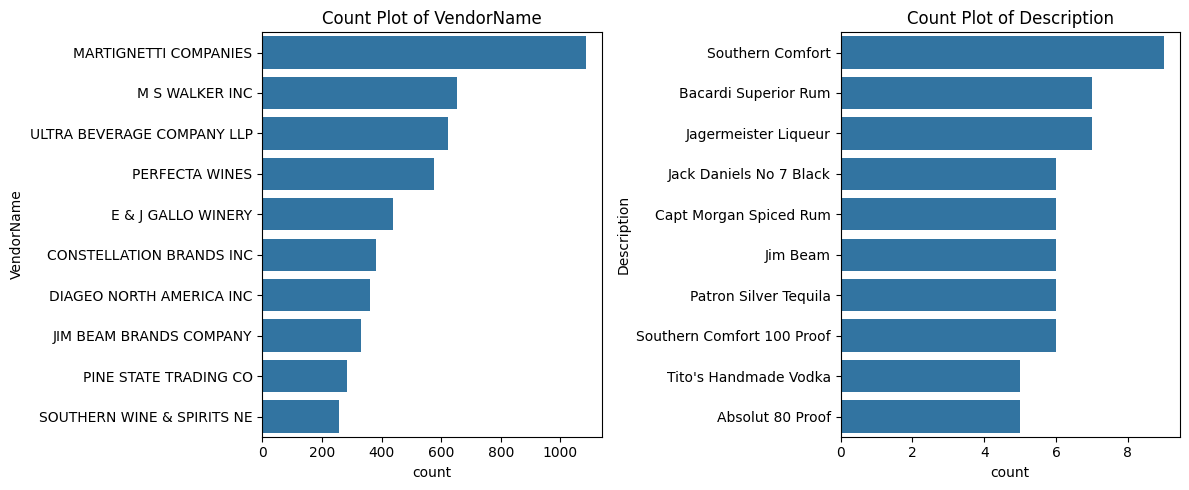

In [7]:
# Count Plot for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])  # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

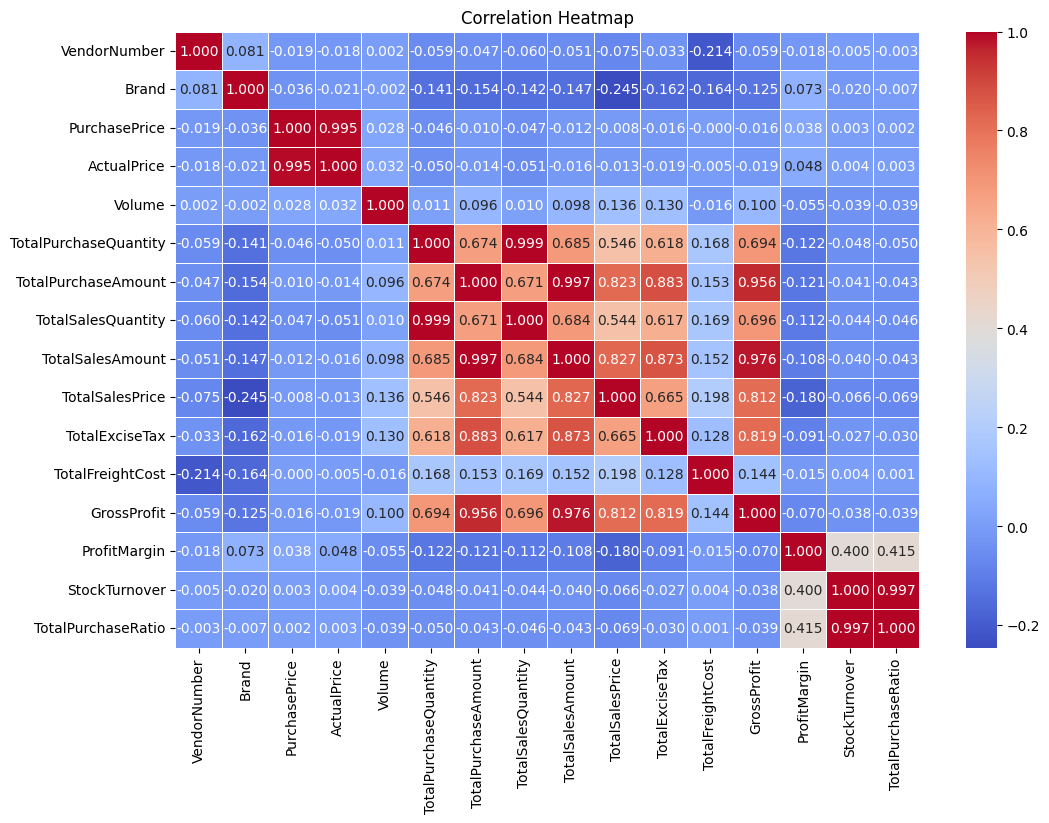

In [8]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".3f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Correlation Insights
- PurchasePrice has weak correlations with TotalSalesAmount (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
- Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
- Negative correlation between profit margin & total sales price (-0.180) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.
- StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.
- Purchase_Price <-> Actual_price = 0.99 Price are almost identical that mean vary strong correlation.
- Total_sales_dollars <-> Gross_Profit = 0.98 that means more sales = mre profit.
- Total_purchase_quantity <-> Ttal_sales_quantity = 1.00 Inventory purchase is almost fully sold.

## Negative Correlation ( 0 to -1)
#### Meaning: One increases, the other decreases
- VendorNumber has slightly negative correlation with many variables ( ~ -0.05 to 0.21). Although Vendor ID itself dosen't impact buisiness metrics.
- Profit_margins vs Total_sales_price = negative, Higher selling price may not always increase margin (possible discounting or cost issues)
## Near zero Correlation
#### Meaning: No relationship
- Volume vs many variables = 0, Vlume is not enugh stringly effecting revenue or Profit.
## Some strong insights
- Freight cost has weak correlation with sales/profit. Although logistics cost is not a major driver of profit.
- Margin: Profit margin has weak/negative correlation with sales. means increasing sales does not guarantee higher margins.
- Possible reasons: Discounts, High cost of goods.


# Data Analysis
### 1. Identify Brands that need Promotional and pricing Adjusments which exihibit lower sales Performance but higher profit margins.

In [9]:
brand_performance = df.groupby('Description').agg({'TotalSalesAmount':'sum', 'ProfitMargin':'mean'}).reset_index()
brand_performance

,Description,TotalSalesAmount,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.525675
7703,Zuccardi Q Malbec,1639.18,23.981503
7704,Zum Rsl,10857.34,32.675038
7705,Zwack Liqueur,227.88,16.653502


In [10]:
low_sales_threshold  = brand_performance['TotalSalesAmount'].quantile(0.15)
high_sales_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [11]:
low_sales_threshold

np.float64(560.299)

In [12]:
high_sales_threshold

np.float64(64.97017552750113)

In [13]:
target_brands = brand_performance[(brand_performance['TotalSalesAmount']<= low_sales_threshold)
                                  & (brand_performance['ProfitMargin'] >= high_sales_threshold)
                                  ]
print('Brands with Low sales, but high profit margins..')
display(target_brands.sort_values('TotalSalesAmount'))

Brands with Low sales, but high profit margins..


,Description,TotalSalesAmount,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [14]:
brand_performance = brand_performance[brand_performance['TotalSalesAmount'] < 1000]

In [15]:
print(brand_performance.shape)

(1646, 3)


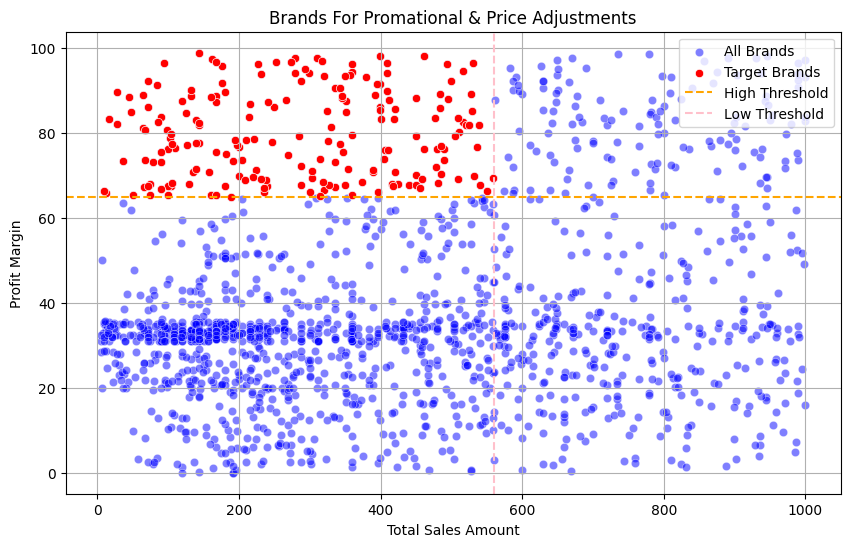

In [16]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = brand_performance, x= "TotalSalesAmount", y= "ProfitMargin", color = 'blue', label = "All Brands", alpha = 0.5)
sns.scatterplot(data = target_brands, x= 'TotalSalesAmount', y="ProfitMargin", color = 'red', label = 'Target Brands')
plt.axhline(high_sales_threshold, linestyle = '--', color = 'Orange', label = 'High Threshold')
plt.axvline(low_sales_threshold, linestyle = '--', color = 'pink', label = 'Low Threshold')

plt.xlabel('Total Sales Amount')
plt.ylabel('Profit Margin')
plt.title('Brands For Promational & Price Adjustments')
plt.legend()
plt.grid(True)
plt.show()

### 2. Which Vendor and Brands demonstrate the highest sales performance?

In [17]:
def format_amounts(value):
    if value >= 1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value/1_000:.2f}K"
    else:
        return str(value)

In [18]:
#Top Vendors and Brands by Sales Performance

top_vendors = df.groupby('VendorName') ['TotalSalesAmount'].sum().nlargest(10)
top_brands = df.groupby('Description') ['TotalSalesAmount'].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesAmount, dtype: float64

In [19]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesAmount, dtype: float64

In [20]:
top_vendors.apply (lambda x : format_amounts(x))

VendorName
DIAGEO NORTH AMERICA INC      67.99M
MARTIGNETTI COMPANIES         39.33M
PERNOD RICARD USA             32.06M
JIM BEAM BRANDS COMPANY       31.42M
BACARDI USA INC               24.85M
CONSTELLATION BRANDS INC      24.22M
E & J GALLO WINERY            18.40M
BROWN-FORMAN CORP             18.25M
ULTRA BEVERAGE COMPANY LLP    16.50M
M S WALKER INC                14.71M
Name: TotalSalesAmount, dtype: str

In [21]:
top_brands.apply (lambda x : format_amounts(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesAmount, dtype: str

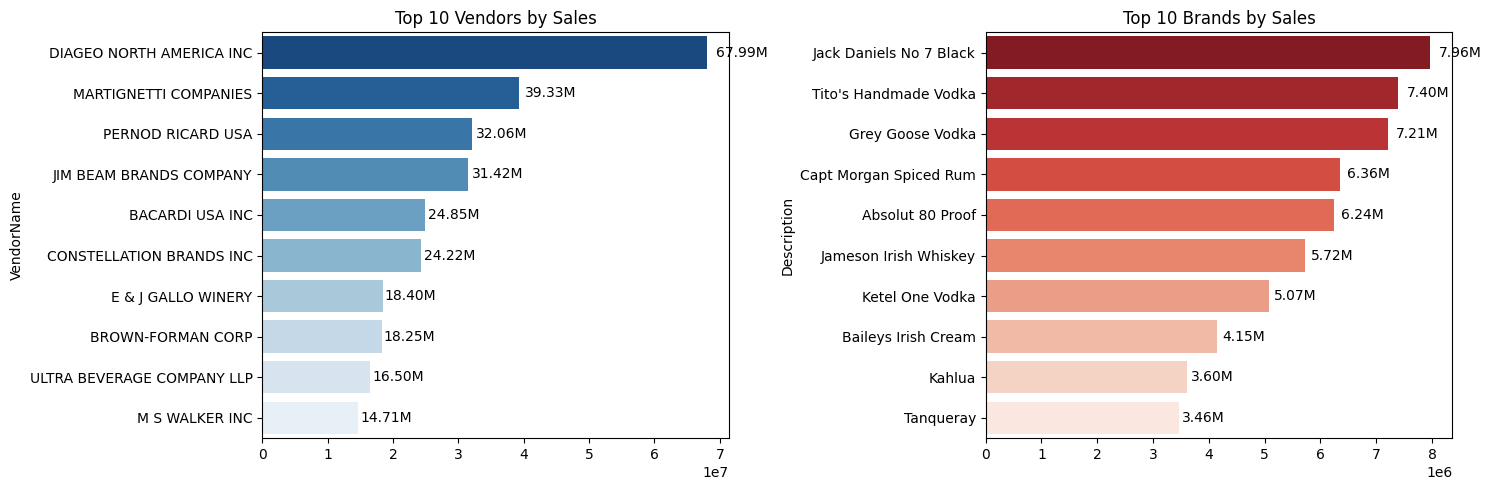

In [22]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02), 
             bar.get_y() + bar.get_height() / 2, 
             format_amounts(bar.get_width()), 
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02), 
             bar.get_y() + bar.get_height() / 2, 
             format_amounts(bar.get_width()), 
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

### 3. Which vendors contribute the most to total purchase amount?

In [23]:
# Rank Vendors by Total Purchase Dollars
vendor_performance = df.groupby("VendorName").agg({
    "TotalPurchaseAmount": "sum",
    "GrossProfit": "sum",
    "TotalSalesAmount":"sum"
}).reset_index()


In [24]:
# Adding Calculate Contribution % Column
vendor_performance["Purchase_Contribution%"] = (vendor_performance["TotalPurchaseAmount"] / vendor_performance["TotalPurchaseAmount"].sum()) * 100


In [25]:
# Rank Vendors by Total Purchase Dollars & Profitability
vendor_performance = round(vendor_performance.sort_values(by="TotalPurchaseAmount", ascending=False),2)


In [26]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesAmount'] = top_vendors['TotalSalesAmount'].apply(format_amounts)
top_vendors['TotalPurchaseAmount'] = top_vendors['TotalPurchaseAmount'].apply(format_amounts)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_amounts)
top_vendors

,VendorName,TotalPurchaseAmount,GrossProfit,TotalSalesAmount,Purchase_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


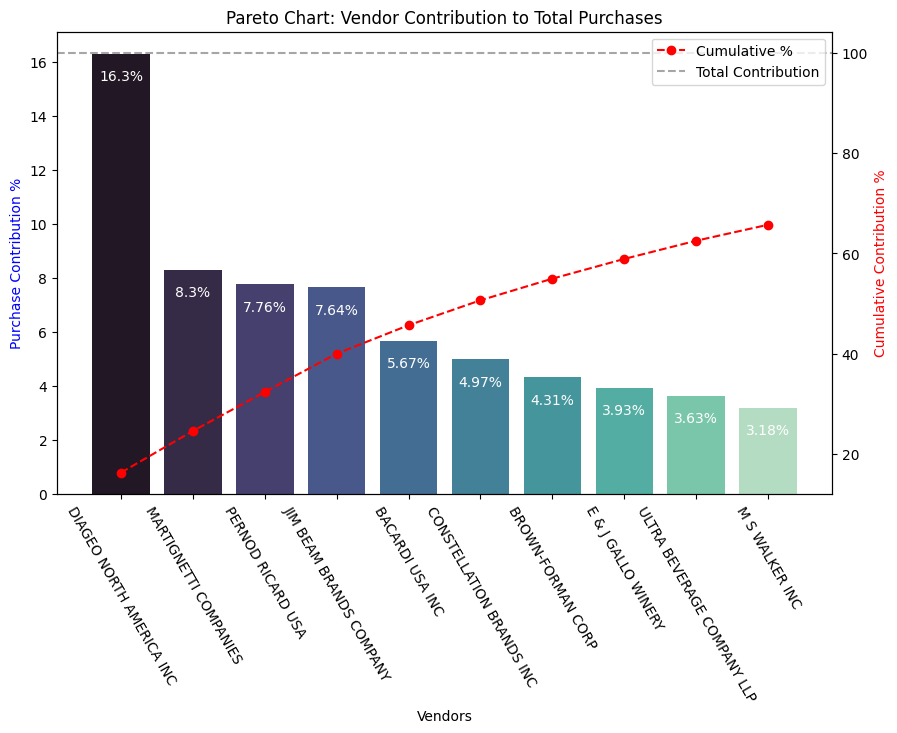

In [27]:
top_vendors['Cumulative_Contribution%'] = top_vendors['Purchase_Contribution%'].cumsum()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['Purchase_Contribution%'],  palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['Purchase_Contribution%']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative %')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=-60)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7, label = 'Total Contribution')
ax2.legend(loc='upper right')

plt.show()

### 4. How much of total procurement is dependent on the top vendors?

In [28]:
print(f'Total purchase contribution of TOp 10 Vendors is.., {round(top_vendors['Purchase_Contribution%'].sum(), 2)}%')

Total purchase contribution of TOp 10 Vendors is.., 65.69%


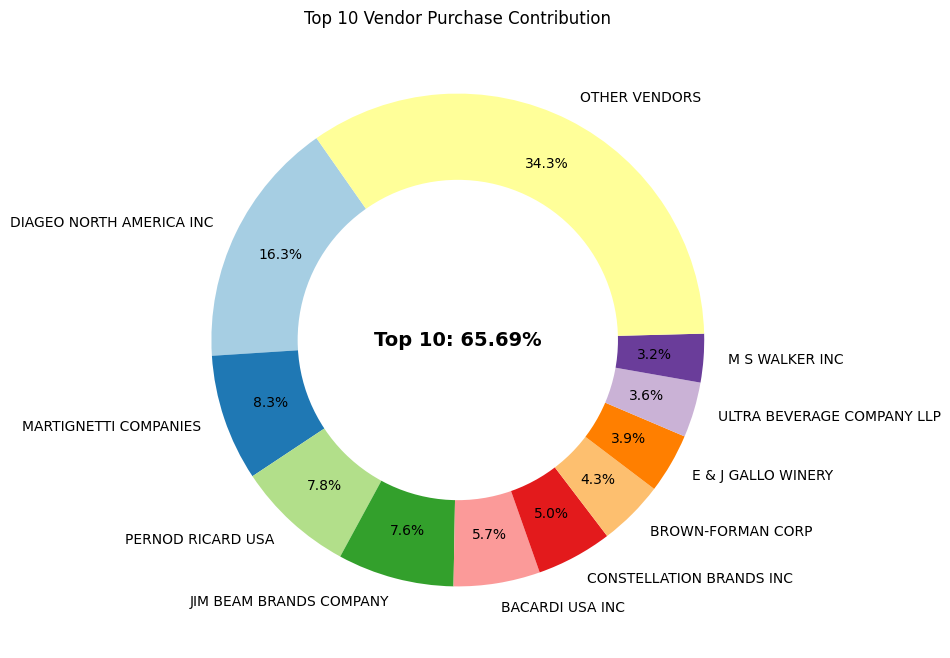

In [29]:
vendors = list(top_vendors['VendorName'].values)
purchase_contribution = list(top_vendors['Purchase_Contribution%'].values)

#Total contribution by top 10 vendors
total_contributions = sum(purchase_contribution)
remaining_contribution = 100 - total_contributions

#append 'other vendors'
vendors.append('OTHER VENDORS')
purchase_contribution.append(remaining_contribution)

# Chart preprations (Donut)
fig, ax = plt.subplots(figsize = (8, 8))

wedges, texts, autotexts = ax.pie(
purchase_contribution,
labels = vendors,
autopct = '%1.1f%%',
startangle = 125,
pctdistance = 0.80,
colors = plt.cm.Paired.colors)

#creating donut hole
centre_circle = plt.Circle((0, 0), 0.65, fc ='white')
fig.gca().add_artist(centre_circle) #GCA = Get Current Access

#Centre Text
plt.text(0, 0, f"Top 10: {total_contributions:.2f}%",
        fontsize = 14,
        fontweight = 'bold',
        ha = 'center',
        va = 'center'
)

plt.title('Top 10 Vendor Purchase Contribution')
plt.show()

### 5. Does Purchasing bulk reduce the unit price, and what is the optimal purchase volume for cost savings.

In [30]:
# Calculate Unit Purchase Price per Vendor & Volume Group
df['UnitPurchasePrice'] = df['TotalPurchaseAmount'] / df['TotalPurchaseQuantity']

In [31]:
# Group by Order Sizes (e.g., Small, Medium, Large Purchases)
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'], q = 3, labels= ['Small', 'Medium', 'Large'])

In [32]:
# Analyze Cost Savings per Order Size
BulkPurchase = df.groupby('OrderSize')['UnitPurchasePrice'].mean().reset_index()
BulkPurchase

,OrderSize,UnitPurchasePrice
0,Small,39.068186
1,Medium,15.486414
2,Large,10.777625


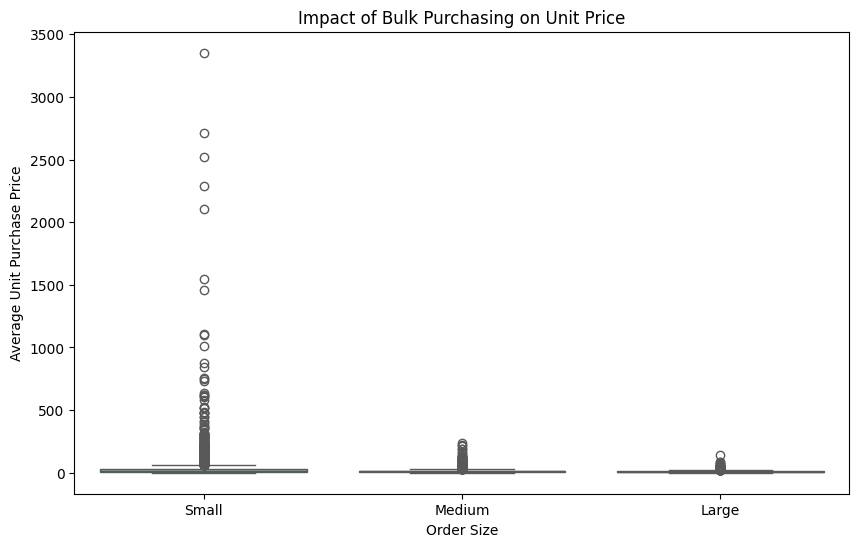

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

- Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
- The price difference between Small and Large orders is substantial (~72% reduction in unit cost)
- This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

#### 6. Which vendors have low inventory turnover, indicating excess stock and slow-moving products?

In [34]:
# Low Inventory Turnover Vendors, turnover less then 1 means they have low sales and huge stock
low_turnover_vendors = df[df["StockTurnover"] < 1].groupby("VendorName")["StockTurnover"].mean().reset_index().sort_values(by="StockTurnover", ascending=True).head(10)
low_turnover_vendors


,VendorName,StockTurnover
0,ALISA CARR BEVERAGES,0.615385
36,HIGHLAND WINE MERCHANTS LLC,0.708333
60,PARK STREET IMPORTS LLC,0.751306
19,Circa Wines,0.755676
26,Dunn Wine Brokers,0.766022
15,CENTEUR IMPORTS LLC,0.773953
78,SMOKY QUARTZ DISTILLERY LLC,0.783835
90,TAMWORTH DISTILLING,0.797078
91,THE IMPORTED GRAPE LLC,0.807569
101,WALPOLE MTN VIEW WINERY,0.820548


- Slow-moving inventory increases holding costs (warehouse rent, insurance, depreciation)
- Identifying vendors with low inventory turnover is critical for business efficiency, cost reduction, and profitability


#### 6. How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

In [ ]:

#Calculate Unsold Units
df["UnsoldUnits"] = df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]

#Fix negative values
df["UnsoldUnits"] = df["UnsoldUnits"].clip(lower=0)

#Calculate Unsold Inventory Value
df["UnsoldInventoryValue"] = df["UnsoldUnits"] * df["PurchasePrice"]

#Total capital locked
total_unsold = df["UnsoldInventoryValue"].sum()
print("Total Unsold Capital:", format_amounts(total_unsold))

#Aggregate per vendor
inventory_value_per_vendor = (
    df.groupby("VendorName")["UnsoldInventoryValue"]
    .sum()
    .reset_index()
)

#Sort vendors by highest locked capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(
    by="UnsoldInventoryValue", ascending=False
)

#Keep raw copy (for future analysis)
inventory_value_per_vendor_raw = inventory_value_per_vendor.copy()

#Format values for display
inventory_value_per_vendor["UnsoldInventoryValue"] = inventory_value_per_vendor[
    "UnsoldInventoryValue"
].apply(format_amounts)

#top 10 vendors
inventory_value_per_vendor.head(10)

Total Unsold Capital: 9.55M


,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,1.40M
57,MARTIGNETTI COMPANIES,882.51K
46,JIM BEAM BRANDS COMPANY,833.26K
68,PERNOD RICARD USA,638.98K
106,ULTRA BEVERAGE COMPANY LLP,506.53K
116,WILLIAM GRANT & SONS INC,468.09K
30,E & J GALLO WINERY,399.97K
20,CONSTELLATION BRANDS INC,346.40K
67,PERFECTA WINES,344.63K
11,BROWN-FORMAN CORP,337.28K


### Handling Negative Inventory Issue

While calculating unsold inventory, we found cases where sales were higher than purchases.

This happens because sales can come from previous stock (old inventory).

To fix this:
- Negative unsold units are converted to 0
- This ensures accurate calculation of unsold inventory value

#### 7. What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


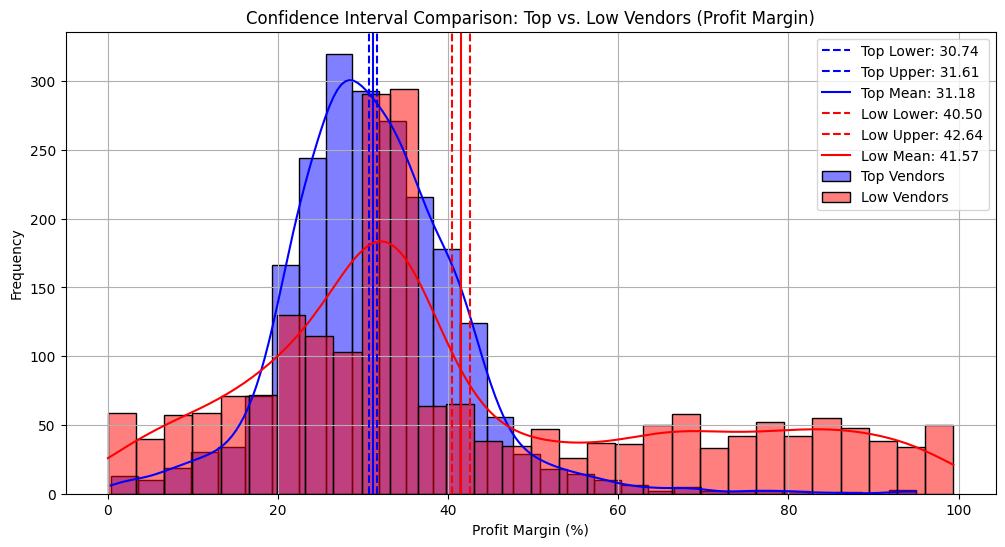

In [36]:
# Define top and low vendors based on Total Sales Dollars (Top 25% & Bottom 25%)
top_threshold = df["TotalSalesAmount"].quantile(0.75)
low_threshold = df["TotalSalesAmount"].quantile(0.25)

top_vendors = df[df["TotalSalesAmount"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesAmount"] <= low_threshold]["ProfitMargin"].dropna()

# Function to compute confidence interval
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

# Compute confidence intervals
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


- The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).
- This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
- For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
- For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

#### 8. Is there a significant difference in profit margins between top-performing and low-performing vendors?

Hypothesis:

H₀ (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H₁ (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [37]:

top_threshold = df["TotalSalesAmount"].quantile(0.75)
low_threshold = df["TotalSalesAmount"].quantile(0.25)

top_vendors = df[df["TotalSalesAmount"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesAmount"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")


T-Statistic: -17.6695, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.


- A p-value this small suggests that the difference is not just statistically significant but also practically meaningful.

- The two vendor groups operate very differently in terms of profitability.

In [38]:
df.to_csv('vendor_sales_summary.csv',index = False)